# Convolutional Neural Networks

The [artificial neural network](ann.ipynb) of the previous section is a
*fully connected* model: every input connects to every neuron in the next layer.
That is a lot of freedom, and for **spatial data** (images, and gridded climate
fields), most of it is wasted. This section introduces the **convolutional neural
network (CNN)**, a regularized neural network built specifically to process images
and any data with spatial structure. We will:

- Define the **convolutional neural network** and see where its efficiency comes from.
- Survey the main **applications** of CNNs, in computer vision and in climate and
  environmental research.
- Walk through the operations that make up a CNN (**convolution, stride, pooling,
  padding**) and the steps to design and train one.
- Define **transfer learning** and understand how to reuse pre-trained models.

As with the ANN page, every figure below is generated from a few lines of `numpy`
and one of scikit-learn's bundled toy images, so you can watch each operation happen
rather than take it on faith.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

np.random.seed(0)

## From a fully connected network to a convolution

A fully connected (feed-forward, multilayer-perceptron) network makes **no
assumption** about how its inputs are arranged: pixel (0, 0) and pixel (95, 143) are
treated as interchangeable coordinates in one long vector. But in an image, pixels
that are **spatially close carry related information**: an edge, a texture, a storm
front. A CNN builds this in as a **spatial inductive bias**: instead of one weight per
input–output pair, it learns a small **filter** (also called a *kernel*) of weights and
**slides it across the image**, reusing the same weights at every location.

This is the "regularized neural network" idea: weight sharing dramatically reduces the
number of parameters and forces the network to look for *local* patterns that are
useful *anywhere* in the image. (On Tuesday we will meet **recurrent neural networks**,
which encode a different inductive bias, one for *sequential* data such as time
series, but the CNN's bias is spatial.)

## What CNNs are used for

CNNs grew out of **computer vision**: using machine learning to analyze images and
videos (a video being a sequence of images). A few canonical tasks, each of which asks
a different question of the same picture:

- **Classification**: *what* is in the image? (cat vs. dog)
- **Classification + localization**: what, and *where* is the single object?
- **Semantic segmentation**: label *every pixel* by class (grass, cat, sky, tree). It
  classifies pixels, not objects, so it tells you *where* a class is but not *how many*.
- **Object detection / instance segmentation**: find *multiple* objects and separate
  them (three dogs, and which pixels belong to each).

### In remote sensing and climate

These tasks are enormously useful for **remote sensing**, where we now hold terabytes
to petabytes of satellite imagery. A CNN can sweep through it far faster than any human:

- **Object detection**: locate every airplane on an airport apron, or map every
  solar panel on Earth for downstream energy studies.
- **Instance segmentation for storm detection**: a storm system is not a neatly
  defined variable in a climate model, but a CNN can be trained to outline where
  **tropical cyclones** and **atmospheric rivers** sit in a model field. Run that over
  ~100 years of model output and you get storm counts and locations that would be
  impractical to extract by hand.
- **Contrails and aviation climate effects**: contrails are high-altitude cirrus
  clouds that form from aircraft exhaust; in the right conditions they **trap outgoing
  longwave radiation**, a *warming* (positive) forcing in the same direction as CO₂.
  Recent work suggests contrails may contribute **more than 60%** of aviation's climate
  forcing, more than the CO₂ from the fuel itself. Whether a given flight makes a
  long-lived contrail is very hard to model, so groups such as **Google's Project
  Contrails** hand-label contrail masks in **GOES-16** satellite imagery and train CNNs
  to detect them, then apply the model back to the full satellite record.
- **Other environmental applications**: classify a catchment as flooded or not, label
  a scene as forest / non-forest, outline individual rock glaciers, or identify every
  tree in an image (and monitor all of these over time).

A climate-model field can be treated like an image, though it may have **many more
channels** than an ordinary picture, which brings us to how the convolution actually
works.

## The convolution operation

### One dimension first

The simplest case is a **1-D convolution**. We have a short kernel of learnable
**weights** and a longer signal. We slide the kernel along the signal and, at each
position, output the **weighted sum** of the input value and its neighbours. It is
simple and computationally inexpensive.

Below, the signal is mostly zeros with a single spike. Convolving it with a small
averaging kernel spreads the spike over its neighbours; convolving with an
edge-detection kernel `[-1, 0, 1]` responds only where the signal *changes*. The
weights shown here are fixed for illustration. In a real CNN **these are exactly the
numbers the network learns during training.**

input signal : [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
smoothed     : [0.   0.   0.   0.   0.   0.33 0.33 0.33 0.   0.   0.   0.   0.  ]
edge-filtered: [ 0  0  0  0  0 -1  0  1  0  0  0  0  0]


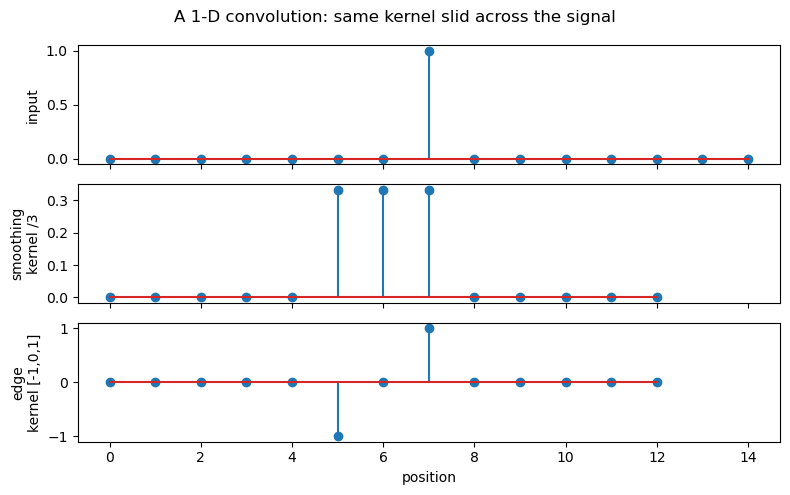

In [2]:
def conv1d(signal, kernel):
    # 'valid' 1-D convolution: slide the (flipped) kernel over the signal
    k = kernel[::-1]
    out = np.array([np.dot(signal[i:i+len(k)], k)
                    for i in range(len(signal) - len(k) + 1)])
    return out

signal = np.zeros(15); signal[7] = 1.0            # a single spike
smooth = np.array([1, 1, 1]) / 3.0                # local average
edge   = np.array([-1, 0, 1])                      # responds to change

print("input signal :", signal.astype(int))
print("smoothed     :", np.round(conv1d(signal, smooth), 2))
print("edge-filtered:", conv1d(signal, edge).astype(int))

fig, ax = plt.subplots(3, 1, figsize=(8, 5), sharex=True)
ax[0].stem(signal); ax[0].set_ylabel("input")
ax[1].stem(conv1d(signal, smooth)); ax[1].set_ylabel("smoothing\nkernel /3")
ax[2].stem(conv1d(signal, edge)); ax[2].set_ylabel("edge\nkernel [-1,0,1]")
ax[2].set_xlabel("position")
fig.suptitle("A 1-D convolution: same kernel slid across the signal")
plt.tight_layout(); plt.show()

### Two dimensions

For images we slide a **2-D kernel** (often a small **3×3 receptive field**) across
the array. At each location the kernel's weights multiply the pixels underneath and are
summed to a single output value; the result is a **convolved feature map** that becomes
the input to the next layer.

Different kernels extract different features. Below we take one handwritten digit from
scikit-learn's bundled `load_digits` (an 8×8 grayscale image) and pass a **blur**
kernel and two **edge-detection (Sobel)** kernels over it. The blur smooths; the Sobel
kernels light up **vertical** and **horizontal** edges respectively. A trained CNN
learns a whole bank of such kernels automatically.

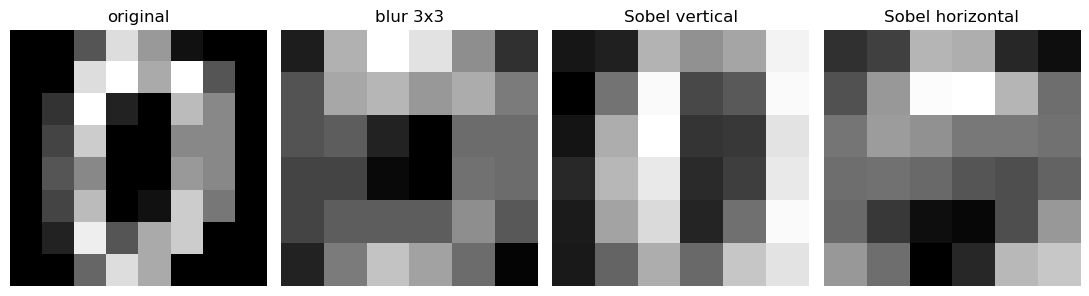

In [3]:
def conv2d(img, kernel):
    # 'valid' 2-D convolution (correlation with a flipped kernel), plain numpy
    k = kernel[::-1, ::-1]
    kh, kw = k.shape
    H, W = img.shape
    out = np.zeros((H - kh + 1, W - kw + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            out[i, j] = np.sum(img[i:i+kh, j:j+kw] * k)
    return out

img = load_digits().images[0]                      # one 8x8 digit

blur      = np.ones((3, 3)) / 9.0
sobel_v   = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])   # vertical edges
sobel_h   = sobel_v.T                                         # horizontal edges

fig, ax = plt.subplots(1, 4, figsize=(11, 3))
for a, (title, out) in zip(ax, [
        ("original", img),
        ("blur 3x3", conv2d(img, blur)),
        ("Sobel vertical", conv2d(img, sobel_v)),
        ("Sobel horizontal", conv2d(img, sobel_h))]):
    a.imshow(out, cmap="gray"); a.set_title(title); a.axis("off")
plt.tight_layout(); plt.show()

### Multiple channels

A colour image is not a single array but **three channels**: red, green, blue. A
convolutional layer handles this by giving each kernel a depth matching the input, then
**summing over the channels** (as well as over height and width) to produce each output
value. A layer also learns not one but **many filters**, so its output has as many
channels as it has filters. Climate-model fields work the same way, often with many
more than three channels (temperature, humidity, winds at many levels).

### Stride: moving the filter in bigger steps

The **stride** is *how far the filter moves at each step*. A stride of 1 visits every
position (as above). A **larger stride skips positions**, producing fewer outputs and
therefore a **smaller feature map** than the input.

Why shrink on purpose? For a task like classification we want to funnel a
128×128 image down to a single class probability (a softmax over classes), so reducing
spatial size as we go deeper is exactly what we want.

In [4]:
def conv2d_stride(img, kernel, stride):
    k = kernel[::-1, ::-1]; kh, kw = k.shape; H, W = img.shape
    rows = range(0, H - kh + 1, stride); cols = range(0, W - kw + 1, stride)
    return np.array([[np.sum(img[i:i+kh, j:j+kw] * k) for j in cols] for i in rows])

img16 = load_digits().images[0]   # 8x8
for s in (1, 2, 3):
    out = conv2d_stride(img16, blur, stride=s)
    print(f"stride {s}: 8x8 input, 3x3 kernel  ->  output {out.shape}")

stride 1: 8x8 input, 3x3 kernel  ->  output (6, 6)
stride 2: 8x8 input, 3x3 kernel  ->  output (3, 3)
stride 3: 8x8 input, 3x3 kernel  ->  output (2, 2)


### Pooling: shrinking without weights

Another way to shrink a feature map is a **pooling layer**. Unlike a convolution,
pooling has **no learnable weights**; it just summarizes each little patch. **Max
pooling** keeps the largest value in each 2×2 block; **average (mean) pooling** keeps
the mean. A 2×2 pool turns four pixels into one, compressing the image by a factor of
four while keeping its overall structure.

original: (8, 8)  pooled: (4, 4)


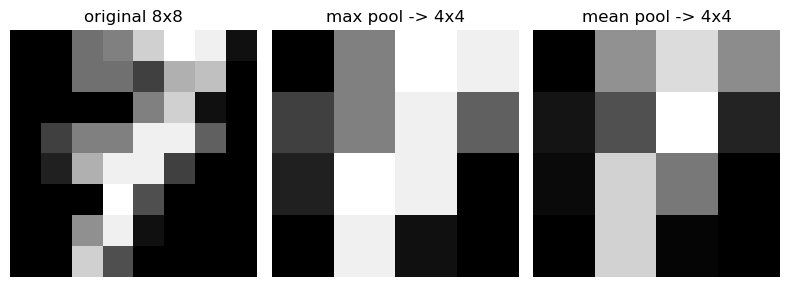

In [5]:
def pool2x2(img, mode="max"):
    H, W = img.shape; H -= H % 2; W -= W % 2      # trim to even size
    blocks = img[:H, :W].reshape(H // 2, 2, W // 2, 2)
    return blocks.max((1, 3)) if mode == "max" else blocks.mean((1, 3))

img8 = load_digits().images[7]
fig, ax = plt.subplots(1, 3, figsize=(8, 3))
for a, (title, out) in zip(ax, [("original 8x8", img8),
                                ("max pool -> 4x4", pool2x2(img8, "max")),
                                ("mean pool -> 4x4", pool2x2(img8, "mean"))]):
    a.imshow(out, cmap="gray"); a.set_title(title); a.axis("off")
print("original:", img8.shape, " pooled:", pool2x2(img8).shape)
plt.tight_layout(); plt.show()

## Building a convolutional neural network

Put these pieces together and a typical CNN looks like:

1. **Prepare and load** the image dataset.
2. A **series of convolution and pooling layers**, which progressively extract
   higher-level features while shrinking the spatial size.
3. A **flatten** layer that turns the final 2-D feature maps into a single vector.
4. A few **dense (fully connected) layers**, the same kind as in the ANN, ending, for
   classification, in a **softmax** over classes.

CNNs expose **even more hyperparameters** than a plain neural network (kernel size,
number of filters, stride, pooling, how many conv/pool blocks), so architecture design
is, again, "more art than science," guided by rules of thumb and problem-specific
experience rather than one correct answer.

### Not enough data? Augment it

CNNs typically **need more data** than a plain neural network to train well. When you
only have, say, 1000 images, **data augmentation** generates realistic variants of each
training image (**rotations, translations, resizing**, colour shifts), so a cat is
recognized at any size or position. Deep-learning libraries (TensorFlow/Keras) provide
these transforms ready-made. As a **bonus, augmentation regularizes** the model, helping
it generalize to new images.

### Padding: keeping the size fixed

Each convolution **shrinks** the image at the edges (a 3×3 kernel loses a one-pixel
border). When you want the output to stay the **same size** as the input, use **zero
padding**: ring the image with zeros so the kernel has something to sit on at the edge.
In Keras this is the difference between `padding="same"` (pad to preserve size) and
`padding="valid"` (no padding, let the image shrink).

In [6]:
def pad_same(img, k=3):
    p = k // 2
    return np.pad(img, p, mode="constant")

img8 = load_digits().images[0]
print("valid (no padding): 8x8 in ->", conv2d(img8, blur).shape, "  (shrinks)")
print("same  (zero-pad)  : 8x8 in ->", conv2d(pad_same(img8, 3), blur).shape, "  (preserved)")

valid (no padding): 8x8 in -> (6, 6)   (shrinks)
same  (zero-pad)  : 8x8 in -> (8, 8)   (preserved)


### A note on batch size and hardware

CNNs are usually trained on **GPUs**, which are fast but have **limited memory (RAM)**.
A large batch of high-resolution images may not fit, so we train on **smaller batches**
(a subset of the data at a time), as both a memory necessity and, via stochastic gradient
descent, a route to a more generalizable solution. Reducing batch size, using fewer
layers, or increasing strides all lower memory use.

## Transfer learning

Sometimes even with augmentation there is **still not enough data** to train a good CNN
from scratch. **Transfer learning** reuses a model already trained on a large dataset
for a *different* problem.

When computer vision took off in the early 2010s, the community built huge labelled
benchmark datasets (most famously **ImageNet**) and trained strong architectures on
them (**ResNet**, **U-Net**, and others). A network trained on millions of images has
learned, in its convolutional layers, a hierarchy of **higher-level features** (edges,
textures, shapes) that turn out to be useful for **almost any** vision task. So instead
of starting from random weights, we:

1. **Pick a pre-trained model** to reuse (e.g. ResNet).
2. **Load its trained weights**, corresponding to a similar dataset.
3. **Retrain only part of it**: typically **freeze** most layers and retrain just the
   final few dense layers (or the first layers closest to the image, which are most
   specialized to the new input), keeping the general features the rest already learned.

These pre-trained models load directly from libraries like TensorFlow/Keras.

## CNNs and transfer learning in climate science

The same ideas transfer to climate problems, where the recurring question is: *how do
we emulate a complex, high-dimensional, spatial environmental process cheaply?*

- **Spatial emulation.** Because a climate-model field is image-like, a CNN can learn to
  map inputs (e.g. greenhouse-gas concentrations) to a full **2-D temperature map**,
  and, unlike a plain neural network, it can predict that map *directly* without
  flattening away the spatial structure. The [companion tutorial](cnn_tutorial.ipynb) does exactly this on the
  **ClimateBench** dataset (surface-temperature maps from the NorESM2 model driven by
  greenhouse-gas concentrations under different SSP scenarios), comparing a dense
  network against a CNN, which needs no flattening step and reaches comparable
  accuracy with fewer weights.

- **Reducing uncertainty in climate projections via transfer learning.** Projections of
  future surface temperature spread widely by 2100, roughly **2 °C to 4.5 °C** across
  models under a given scenario, because different models parameterize the physics
  differently. We have **many climate models** but only **one observed Earth**. A recent
  approach trains a neural network on the many model outputs (where labels are plentiful)
  and then **transfers** what it learned to the single real-world record, cutting the
  projection uncertainty by up to roughly **50%** depending on the emissions scenario.
  The premise is the transfer-learning premise: models are not the real world, but they
  are **similar enough** that the features learned from them carry over.

CNNs give us a spatial inductive bias well matched to gridded Earth data; transfer
learning lets us borrow strength from large datasets, or from ensembles of climate
models, when our own labelled data is scarce.